In [1]:
import sys
print(sys.executable)


c:\Users\ASUS\Desktop\land\land\Scripts\python.exe


In [2]:
import zipfile
import os

# Define the paths
zip_path = r'C:\Users\ASUS\Desktop\land\archive (2).zip'
extract_to = r'C:\Users\ASUS\Desktop\land\landextract'

# Create the folder if it doesn't exist
if not os.path.exists(extract_to):
    os.makedirs(extract_to)
    print(f"Created folder: {extract_to}")

# Perform the extraction
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Success! Extraction complete.")
    
    # List the files to verify
    files = os.listdir(extract_to)
    print(f"Extracted {len(files)} items: {files[:5]}...") 
except FileNotFoundError:
    print("Error: The ZIP file was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Success! Extraction complete.
Extracted 1 items: ['Semantic segmentation dataset']...


In [7]:
!pip install patchify

^C


In [4]:
%pip install opencv-python

  Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
patchify 0.2.3 requires numpy<2,>=1, but you have numpy 2.4.3 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%pip install opencv-python scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import os
import cv2
from PIL import Image 
import numpy as np 
from patchify import patchify
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from matplotlib import pyplot as plt
import random

In [9]:
minmaxscaler = MinMaxScaler()

In [10]:
import os

# 1. Define your local Windows root folder 
# (Based on your previous extract_to path)
dataset_root_folder = r'C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset'

# 2. Build the path to Tile 1 images
tile1_images = os.path.join(dataset_root_folder, 'Tile 1', 'images')

print(f"Checking Path: {tile1_images}")

# 3. Verification Logic
if os.path.exists(tile1_images):
    print("✅ Success! Found the images.")
    files = os.listdir(tile1_images)
    if files:
        print(f"Sample file: {files[0]}")
    else:
        print("⚠ Folder found, but it is empty!")
else:
    print("❌ Path still not found.")
    
    # Let's help you debug by showing what IS inside landextract
    base_path = r'C:\Users\ASUS\Desktop\land\landextract'
    if os.path.exists(base_path):
        print(f"\nFolders actually inside {base_path}:")
        print(os.listdir(base_path))
    else:
        print(f"\nFATAL: The base folder {base_path} doesn't even exist.")

Checking Path: C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 1\images
✅ Success! Found the images.
Sample file: image_part_001.jpg


  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


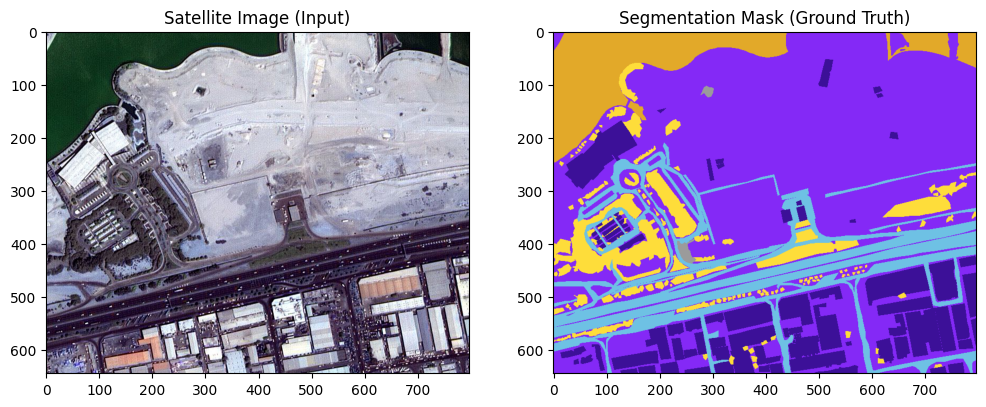

In [12]:
import matplotlib.pyplot as plt
import cv2
import os

# Updated to your confirmed Windows path
base_path = r'C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 1'
image_path = os.path.join(base_path, 'images', 'image_part_008.jpg')
mask_path = os.path.join(base_path, 'masks', 'image_part_008.png') 

# Load and check if they actually exist
if os.path.exists(image_path) and os.path.exists(mask_path):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    mask = cv2.cvtColor(cv2.imread(mask_path), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Satellite Image (Input)")
    plt.imshow(img)

    plt.subplot(1, 2, 2)
    plt.title("Segmentation Mask (Ground Truth)")
    plt.imshow(mask)
    plt.show()
else:
    print("❌ One of the files is missing. Check if 'image_part_008.png' exists in the masks folder.")

In [13]:
import os

# Updated setup variables for VS Code / Windows
dataset_root_folder = r'C:\Users\ASUS\Desktop\land\landextract'
dataset_name = "Semantic segmentation dataset"

# Modified version of your loop
# os.path.join handles the slashes automatically for Windows
root_path = os.path.join(dataset_root_folder, dataset_name)

if os.path.exists(root_path):
    for path, subdirs, files in os.walk(root_path):
        dir_name = os.path.basename(path) # More reliable than split for Windows
        
        # Check for both 'images' and 'masks' folders
        if dir_name.lower() == 'images' or dir_name.lower() == 'masks': 
            files_in_dir = os.listdir(path)
            print(f"✅ Processing: {path}")
            
            for i, file_name in enumerate(files_in_dir):
                # Check for .jpg (images) or .png (masks)
                if file_name.lower().endswith(('.jpg', '.png', '.tif')):
                    # Your logic here
                    pass 
else:
    print(f"❌ ERROR: The path {root_path} does not exist. Please check your folder names.")

✅ Processing: C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 1\images
✅ Processing: C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 1\masks
✅ Processing: C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 2\images
✅ Processing: C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 2\masks
✅ Processing: C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 3\images
✅ Processing: C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 3\masks
✅ Processing: C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 4\images
✅ Processing: C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 4\masks
✅ Processing: C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 5\images
✅ Processing: C:\Users\ASUS\Desktop\land\landextract\Semantic segmentation dataset\Tile 5\masks
✅ Processing: C:\Users\ASUS\Desktop

In [14]:
image_patch_size = 256

In [15]:
image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/Tile 2/images/image_part_001.jpg',1)
image.shape

(544, 509, 3)

In [16]:
image_patches = patchify(image, (image_patch_size, image_patch_size, 3), step=image_patch_size)

In [17]:
len(image_patches)

2

In [18]:
print(image_patches.shape)

(2, 1, 1, 256, 256, 3)


In [19]:
minmaxscaler = MinMaxScaler()

In [20]:
image_x = image_patches[0,0,:,:]
#MinMaxScaler
image_y = minmaxscaler.fit_transform(image_x.reshape(-1, image_x.shape[-1])).reshape(image_x.shape)

In [21]:
image_y[0].shape

(256, 256, 3)

In [22]:
print(type(image))

<class 'numpy.ndarray'>


In [23]:
type(Image.fromarray(image))

PIL.Image.Image

In [24]:
image.shape

(544, 509, 3)

In [25]:
(image.shape[0]//image_patch_size)*image_patch_size

512

In [26]:
image_dataset = []
mask_dataset = []

for image_type in ['images' , 'masks']:
  if image_type == 'images':
    image_extension = 'jpg'
  elif image_type == 'masks':
     image_extension = 'png'
  for tile_id in range(1,8):
    for image_id in range(1,20):
      image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/Tile {tile_id}/{image_type}/image_part_00{image_id}.{image_extension}',1)
      if image is not None:
        if image_type == 'masks':
          image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #print(image.shape)
        size_x = (image.shape[1]//image_patch_size)*image_patch_size
        size_y = (image.shape[0]//image_patch_size)*image_patch_size
        #print("{} --- {} - {}".format(image.shape, size_x, size_y))
        image = Image.fromarray(image)
        image = image.crop((0,0, size_x, size_y))
        #print("({},  {})".format(image.size[0],image.size[1]))
        image = np.array(image)
        patched_images = patchify(image, (image_patch_size, image_patch_size, 3), step=image_patch_size)
        #print(len(patched_images))
        for i in range(patched_images.shape[0]):
          for j in range(patched_images.shape[1]):
            if image_type == 'images':
              individual_patched_image = patched_images[i,j,:,:]
              #print(individual_patched_image.shape)
              individual_patched_image = minmaxscaler.fit_transform(individual_patched_image.reshape(-1, individual_patched_image.shape[-1])).reshape(individual_patched_image.shape)
              individual_patched_image = individual_patched_image[0]
              #print(individual_patched_image.shape)
              image_dataset.append(individual_patched_image)
            elif image_type == 'masks':
              individual_patched_mask = patched_images[i,j,:,:]
              individual_patched_mask = individual_patched_mask[0]
              mask_dataset.append(individual_patched_mask)


In [27]:
print(f"Total patches in dataset: {len(image_dataset)}")
print(f"Total masks in dataset: {len(mask_dataset)}")

# Convert lists to NumPy arrays for training
import numpy as np
X_train = np.array(image_dataset)
Y_train = np.array(mask_dataset)

print(f"Final Input Shape: {X_train.shape}") # Should be (N, 256, 256, 3)

Total patches in dataset: 945
Total masks in dataset: 945
Final Input Shape: (945, 256, 256, 3)


In [28]:
print(len(image_dataset))
print(len(mask_dataset))

945
945


In [29]:
image_dataset = np.array(image_dataset)
mask_dataset = np.array(mask_dataset)

In [30]:
print(len(image_dataset))
print(len(mask_dataset))

945
945


In [31]:
type(image_dataset[0])

numpy.ndarray

In [32]:
type(np.reshape(image_dataset[0], (image_patch_size, image_patch_size, 3)))

numpy.ndarray

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


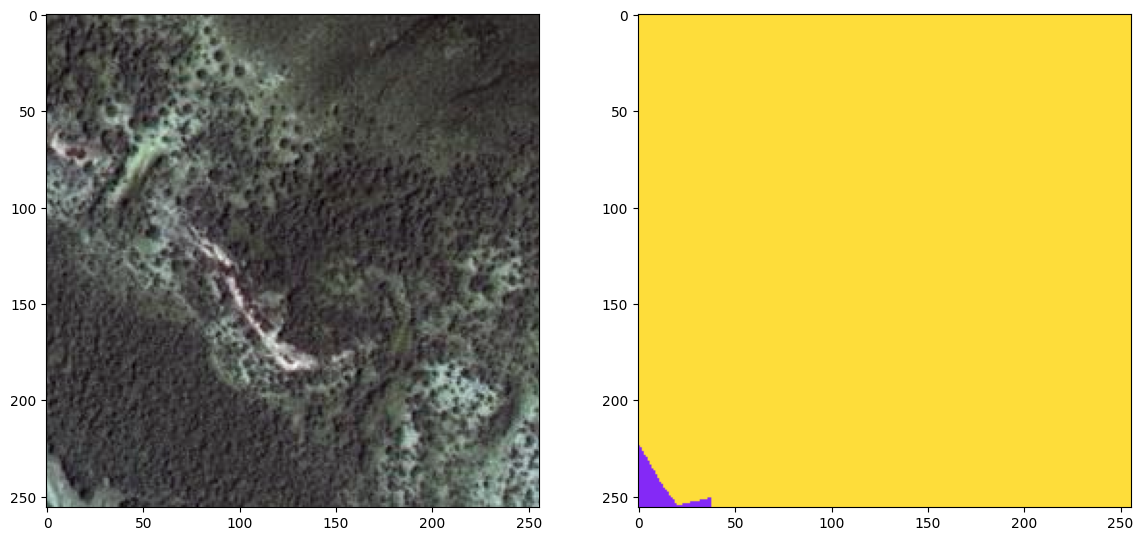

In [33]:
random_image_id = random.randint(0, len(image_dataset))

plt.figure(figsize=(14,8))
plt.subplot(121)
plt.imshow(image_dataset[random_image_id])
plt.subplot(122)
plt.imshow(mask_dataset[random_image_id])

In [34]:
class_building = '#3C1098'
class_building = class_building.lstrip('#')
class_building = np.array(tuple(int(class_building[i:i+2], 16) for i in (0,2,4)))
print(class_building)

class_land = '#8429F6'
class_land = class_land.lstrip('#')
class_land = np.array(tuple(int(class_land[i:i+2], 16) for i in (0,2,4)))
print(class_land)

class_road = '#6EC1E4'
class_road = class_road.lstrip('#')
class_road = np.array(tuple(int(class_road[i:i+2], 16) for i in (0,2,4)))
print(class_road)

class_vegetation = '#FEDD3A'
class_vegetation = class_vegetation.lstrip('#')
class_vegetation = np.array(tuple(int(class_vegetation[i:i+2], 16) for i in (0,2,4)))
print(class_vegetation)

class_water = '#E2A929'
class_water = class_water.lstrip('#')
class_water = np.array(tuple(int(class_water[i:i+2], 16) for i in (0,2,4)))
print(class_water)

class_unlabeled = '#9B9B9B'
class_unlabeled = class_unlabeled.lstrip('#')
class_unlabeled = np.array(tuple(int(class_unlabeled[i:i+2], 16) for i in (0,2,4)))
print(class_unlabeled)

[ 60  16 152]
[132  41 246]
[110 193 228]
[254 221  58]
[226 169  41]
[155 155 155]


In [35]:
mask_dataset.shape[0]

945

In [36]:
label = individual_patched_mask

In [37]:
def rgb_to_label(label):
  label_segment = np.zeros(label.shape, dtype=np.uint8)
  label_segment[np.all(label == class_water, axis=-1)] = 0
  label_segment[np.all(label == class_land, axis=-1)] = 1
  label_segment[np.all(label == class_road, axis=-1)] = 2
  label_segment[np.all(label == class_building, axis=-1)] = 3
  label_segment[np.all(label == class_vegetation, axis=-1)] = 4
  label_segment[np.all(label == class_unlabeled, axis=-1)] = 5
  #print(label_segment)
  label_segment = label_segment[:,:,0]
  #print(label_segment)
  return label_segment

In [38]:
labels = []
for i in range(mask_dataset.shape[0]):
  label = rgb_to_label(mask_dataset[i])
  labels.append(label)

In [39]:
print(len(labels))

945


In [40]:
labels = np.array(labels)

In [41]:
labels[3]

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(256, 256), dtype=uint8)

In [42]:
labels = np.expand_dims(labels, axis=3)

In [43]:
labels[0]

array([[[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]],

       [[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]],

       [[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]],

       ...,

       [[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]],

       [[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]],

       [[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]]], shape=(256, 256, 1), dtype=uint8)

In [44]:
np.unique(labels)

array([0, 1, 2, 3, 4, 5], dtype=uint8)

In [45]:
print("Total unique labels based on masks: ",format(np.unique(labels)))

Total unique labels based on masks:  [0 1 2 3 4 5]


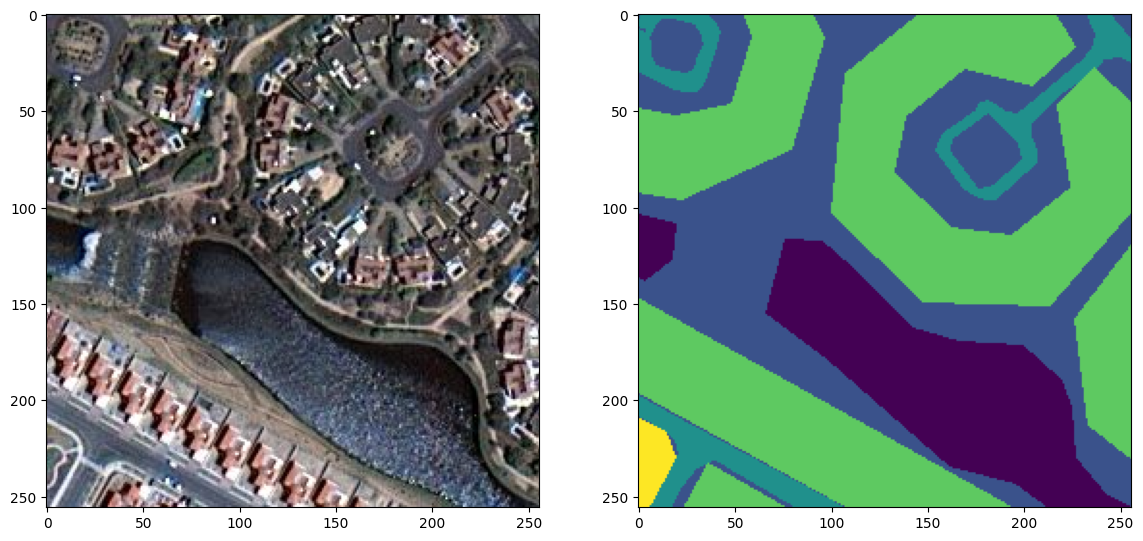

In [46]:
random_image_id = random.randint(0, len(image_dataset))

plt.figure(figsize=(14,8))
plt.subplot(121)
plt.imshow(image_dataset[random_image_id])
plt.subplot(122)
#plt.imshow(mask_dataset[random_image_id])
plt.imshow(labels[random_image_id][:,:,0])

In [47]:
labels[0][:,:,0]

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(256, 256), dtype=uint8)

In [48]:
total_classes = len(np.unique(labels))

In [49]:
total_classes

6

In [50]:
%pip install tensorflow

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
from tensorflow.keras.utils import to_categorical
print("✅ Success: to_categorical imported!")

TensorFlow version: 2.21.0
✅ Success: to_categorical imported!


In [52]:
labels_categorical_dataset = to_categorical(labels, num_classes=total_classes)

In [53]:
labels_categorical_dataset.shape

(945, 256, 256, 6)

In [54]:
# Check the input images
print(image_dataset.shape) 

# Or if you used a different name for the final array:
# print(master_training_dataset.shape)

(945, 256, 256, 3)


In [55]:
master_trianing_dataset = image_dataset
master_trianing_dataset.shape

(945, 256, 256, 3)

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(master_trianing_dataset, labels_categorical_dataset, test_size=0.15, random_state=100)

In [58]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(803, 256, 256, 3)
(142, 256, 256, 3)
(803, 256, 256, 6)
(142, 256, 256, 6)


In [59]:
image_height = X_train.shape[1]
image_width = X_train.shape[2]
image_channels = X_train.shape[3]
total_classes = y_train.shape[3]

In [60]:

print(image_height)
print(image_width)
print(image_channels)
print(total_classes)

256
256
3
6


In [58]:
!pip install -U segmentation-models


   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.9 MB 430.4 kB/s eta 0:00:27
   - -------------------------------------- 0.5/11.9 MB 430.4 kB/s eta 0:00:27
   -- ------------------------------------- 0.8/11.9 MB 532.8 kB/s eta 0:00:21
   -- ------------------------------------- 0.8/11.9 MB 532.8 kB/s eta 0:00:21
   --- ------------------------------------ 1.0/11.9 MB 559.3 kB/s eta 0:00:20
   --- ------------------------------------ 1.0/11.9 MB 559.3 kB/s eta 0:00:20
   --- ------------------------------------ 1.0/11.9 MB 559.3 kB/s eta 0:00:20
   ---- -------------------


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from keras.layers import concatenate, BatchNormalization, Dropout, Lambda

In [62]:
from keras import backend as K

In [86]:
def jaccard_coef(y_true, y_pred):
  y_true_flatten = K.flatten(y_true)
  y_pred_flatten = K.flatten(y_pred)
  intersection = K.sum(y_true_flatten * y_pred_flatten)
  final_coef_value = (intersection + 1.0) / (K.sum(y_true_flatten) + K.sum(y_pred_flatten) - intersection + 1.0)
  return final_coef_value

In [64]:
def multi_unet_model(n_classes=5, image_height=256, image_width=256, image_channels=1):

  inputs = Input((image_height, image_width, image_channels))

  source_input = inputs

  c1 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(source_input)
  c1 = Dropout(0.2)(c1)
  c1 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c1)
  p1 = MaxPooling2D((2,2))(c1)

  c2 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p1)
  c2 = Dropout(0.2)(c2)
  c2 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c2)
  p2 = MaxPooling2D((2,2))(c2)

  c3 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p2)
  c3 = Dropout(0.2)(c3)
  c3 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c3)
  p3 = MaxPooling2D((2,2))(c3)

  c4 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p3)
  c4 = Dropout(0.2)(c4)
  c4 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c4)
  p4 = MaxPooling2D((2,2))(c4)

  c5 = Conv2D(256, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p4)
  c5 = Dropout(0.2)(c5)
  c5 = Conv2D(256, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c5)

  u6 = Conv2DTranspose(128, (2,2), strides=(2,2), padding="same")(c5)
  u6 = concatenate([u6, c4])
  c6 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u6)
  c6 = Dropout(0.2)(c6)
  c6 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c6)

  u7 = Conv2DTranspose(64, (2,2), strides=(2,2), padding="same")(c6)
  u7 = concatenate([u7, c3])
  c7 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u7)
  c7 = Dropout(0.2)(c7)
  c7 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c7)

  u8 = Conv2DTranspose(32, (2,2), strides=(2,2), padding="same")(c7)
  u8 = concatenate([u8, c2])
  c8 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u8)
  c8 = Dropout(0.2)(c8)
  c8 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c8)

  u9 = Conv2DTranspose(16, (2,2), strides=(2,2), padding="same")(c8)
  u9 = concatenate([u9, c1], axis=3)
  c9 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u9)
  c9 = Dropout(0.2)(c9)
  c9 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c9)

  outputs = Conv2D(n_classes, (1,1), activation="softmax")(c9)

  model = Model(inputs=[inputs], outputs=[outputs])
  return model

In [79]:
# Call the function with your specific project dimensions
model = multi_unet_model(
    n_classes=total_classes,       # which is 6
    image_height=image_height,     # which is 256
    image_width=image_width,       # which is 256
    image_channels=image_channels  # which is 3
)

# Compile with your custom Jaccard metric
model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy', jaccard_coef]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]  

 Total params: 1,941,190 (7.41 MB)

 Trainable params: 1,941,190 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
metrics = ["accuracy", jaccard_coef]

In [65]:
print(image_height)
print(image_width)
print(image_channels)
print(total_classes)

256
256
3
6


In [66]:
def get_deep_learning_model():
  return multi_unet_model(n_classes=total_classes, 
                          image_height=image_height, 
                          image_width=image_width, 
                          image_channels=image_channels)

In [67]:

model = get_deep_learning_model()

In [68]:
# Please uncomment this line to get model confiuration
# Ensure there are ZERO spaces before 'model'
model.get_config()

{'name': 'functional_1',
 'trainable': True,
 'layers': [{'module': 'keras.layers',
   'class_name': 'InputLayer',
   'config': {'batch_shape': (None, 256, 256, 3),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_layer_1',
    'optional': False},
   'registered_name': None,
   'name': 'input_layer_1',
   'inbound_nodes': []},
  {'module': 'keras.layers',
   'class_name': 'Conv2D',
   'config': {'name': 'conv2d_19',
    'trainable': True,
    'dtype': {'module': 'keras',
     'class_name': 'DTypePolicy',
     'config': {'name': 'float32'},
     'registered_name': None},
    'filters': 16,
    'kernel_size': (3, 3),
    'strides': (1, 1),
    'padding': 'same',
    'data_format': 'channels_last',
    'dilation_rate': (1, 1),
    'groups': 1,
    'activation': 'relu',
    'use_bias': True,
    'kernel_initializer': {'module': 'keras.initializers',
     'class_name': 'HeNormal',
     'config': {'seed': None},
     'registered_name': None},
    'bias_ini

In [69]:

weights = [0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666]

In [70]:
import os
os.environ['SM_FRAMEWORK'] = 'tf.keras'
import segmentation_models as sm

Segmentation Models: using `tf.keras` framework.


In [71]:
dice_loss = sm.losses.DiceLoss(class_weights = weights)

In [72]:


focal_loss = sm.losses.CategoricalFocalLoss()
     

total_loss = dice_loss + (1 * focal_loss)

In [73]:
import tensorflow as tf


In [76]:
tf.keras.backend.clear_session()

In [81]:
model.compile(optimizer="adam", loss=total_loss, metrics=metrics)

In [82]:

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]  

 Total params: 1,941,190 (7.41 MB)

 Trainable params: 1,941,190 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
import tensorflow as tf

def jaccard_coef(y_true, y_pred):
    # Standardize types to float32
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Use reshape instead of K.flatten
    y_true_flatten = tf.reshape(y_true, [-1])
    y_pred_flatten = tf.reshape(y_pred, [-1])
    
    # Use reduce_sum instead of K.sum
    intersection = tf.reduce_sum(y_true_flatten * y_pred_flatten)
    
    # Calculate Jaccard (Intersection over Union)
    union = tf.reduce_sum(y_true_flatten) + tf.reduce_sum(y_pred_flatten) - intersection
    
    # Adding 1.0 (smooth factor) to avoid division by zero
    return (intersection + 1.0) / (union + 1.0)

def jaccard_coef_loss(y_true, y_pred):
    return -jaccard_coef(y_true, y_pred)

In [91]:
import tensorflow as tf
tf.keras.backend.clear_session()
import segmentation_models as sm

# Ensure your weights are defined
weights = [0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666]
dice_loss = sm.losses.DiceLoss(class_weights=weights)
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)

# Re-compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=total_loss,
    metrics=["accuracy", jaccard_coef]
)
print(f"X_train shape: {X_train.shape}") # Should be (803, 256, 256, 3)
print(f"y_train shape: {y_train.shape}") # Should be (803, 256, 256, 6)


X_train shape: (803, 256, 256, 3)
y_train shape: (803, 256, 256, 6)


In [84]:
model_history = model.fit(X_train, y_train,
                          batch_size=16,
                          verbose=1,
                          epochs=100,
                          validation_data=(X_test, y_test),
                          shuffle=False)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5458 - jaccard_coef: 0.2733 - loss: 1.0007 - val_accuracy: 0.6631 - val_jaccard_coef: 0.3517 - val_loss: 0.9905
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.6861 - jaccard_coef: 0.3707 - loss: 0.9816 - val_accuracy: 0.7021 - val_jaccard_coef: 0.4176 - val_loss: 0.9678
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.7269 - jaccard_coef: 0.4641 - loss: 0.9608 - val_accuracy: 0.7063 - val_jaccard_coef: 0.4669 - val_loss: 0.9664
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.7444 - jaccard_coef: 0.4977 - loss: 0.9529 - val_accuracy: 0.7122 - val_jaccard_coef: 0.4759 - val_loss: 0.9663
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.7516 - jaccard_coef: 0.5149 - loss: 0.9488 - val_accuracy: 0.7048 - val_jaccard_coef: 0.4677 - val_loss: 0.9672
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.7583 - jaccard_coef: 0.5244 - loss: 0.9461 -

In [85]:
history_a = model_history

In [86]:
history_a.history

{'accuracy': [0.545777440071106,
  0.6861056089401245,
  0.7268986105918884,
  0.7444455027580261,
  0.7516340613365173,
  0.7582515478134155,
  0.7651256918907166,
  0.7691898941993713,
  0.7776750922203064,
  0.7921537756919861,
  0.7993316650390625,
  0.8066105842590332,
  0.8165770173072815,
  0.8246625661849976,
  0.8215634822845459,
  0.8274691700935364,
  0.8331566452980042,
  0.8380702137947083,
  0.8431208729743958,
  0.8470152616500854,
  0.8512095212936401,
  0.8521518707275391,
  0.8553935885429382,
  0.8569082617759705,
  0.8577278852462769,
  0.8617084622383118,
  0.8618868589401245,
  0.8655574917793274,
  0.8692522048950195,
  0.8701963424682617,
  0.8702618479728699,
  0.8726527094841003,
  0.8713523149490356,
  0.869777500629425,
  0.8734484910964966,
  0.8664608597755432,
  0.8723509907722473,
  0.8761195540428162,
  0.8787032961845398,
  0.8755415081977844,
  0.8753589987754822,
  0.8782451748847961,
  0.870366096496582,
  0.8752245306968689,
  0.8761436939239502,
 

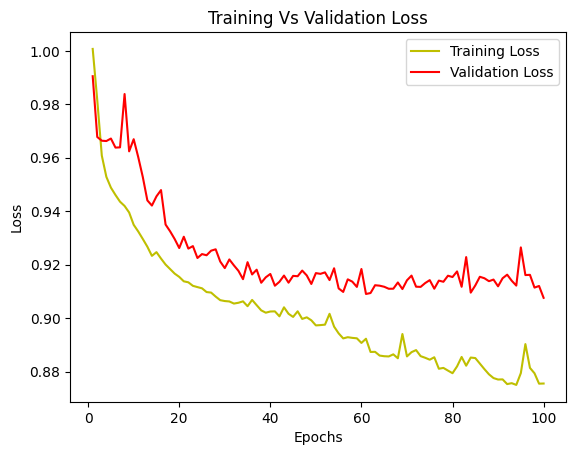

In [87]:
loss = history_a.history['loss']
val_loss = history_a.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label="Training Loss")
plt.plot(epochs, val_loss, 'r', label="Validation Loss")
plt.title("Training Vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

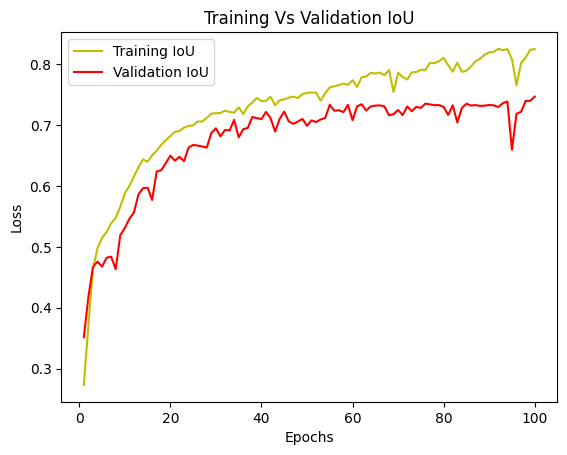

In [88]:
jaccard_coef = history_a.history['jaccard_coef']
val_jaccard_coef = history_a.history['val_jaccard_coef']

epochs = range(1, len(jaccard_coef) + 1)
plt.plot(epochs, jaccard_coef, 'y', label="Training IoU")
plt.plot(epochs, val_jaccard_coef, 'r', label="Validation IoU")
plt.title("Training Vs Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [89]:
model_history.params

{'verbose': 1, 'epochs': 100, 'steps': 51}

In [90]:

y_pred = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 621ms/step


In [91]:
len(y_pred)

142

In [92]:
y_pred

array([[[[1.15032373e-02, 5.87530196e-01, 6.79483637e-02,
          2.92734534e-01, 3.85384746e-02, 1.74518360e-03],
         [2.70383200e-03, 6.49446607e-01, 1.24396645e-02,
          3.26814383e-01, 8.47267825e-03, 1.22796308e-04],
         [1.98033568e-03, 6.86305940e-01, 1.21120261e-02,
          2.95855522e-01, 3.68778408e-03, 5.83486544e-05],
         ...,
         [1.13196988e-02, 8.70250463e-01, 5.65017387e-02,
          2.72273961e-02, 3.44770141e-02, 2.23654963e-04],
         [1.38422577e-02, 8.43893766e-01, 7.27242753e-02,
          3.08801029e-02, 3.83743048e-02, 2.85323069e-04],
         [2.95621902e-02, 7.31592894e-01, 8.26610848e-02,
          9.69269648e-02, 5.72113357e-02, 2.04557530e-03]],

        [[2.56616715e-03, 6.62953973e-01, 2.37740818e-02,
          2.91402847e-01, 1.91055089e-02, 1.97432630e-04],
         [2.85473507e-04, 7.69372821e-01, 4.89390409e-03,
          2.20796019e-01, 4.62200539e-03, 2.98508457e-05],
         [2.40227295e-04, 7.76778877e-01, 4.0171

In [93]:
y_pred_argmax = np.argmax(y_pred, axis=3)

In [94]:
len(y_pred_argmax)

142

In [95]:
y_pred_argmax


array([[[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 2, ..., 1, 1, 1],
        [1, 1, 2, ..., 1, 1, 1],
        ...,
        [2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1]],

       ...,

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [96]:
y_test_argmax = np.argmax(y_test, axis=3)

In [97]:
y_test_argmax



array([[[3, 3, 3, ..., 1, 1, 1],
        [3, 3, 3, ..., 3, 3, 3],
        [3, 3, 3, ..., 3, 3, 3],
        ...,
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        ...,
        [2, 2, 2, ..., 0, 0, 0],
        [2, 2, 2, ..., 0, 0, 0],
        [2, 2, 1, ..., 0, 0, 0]],

       ...,

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [98]:
import random

In [99]:
test_image_number = random.randint(0, len(X_test))

test_image = X_test[test_image_number]
ground_truth_image = y_test_argmax[test_image_number]

test_image_input = np.expand_dims(test_image, 0)

prediction = model.predict(test_image_input)
predicted_image = np.argmax(prediction, axis=3)
predicted_image = predicted_image[0,:,:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


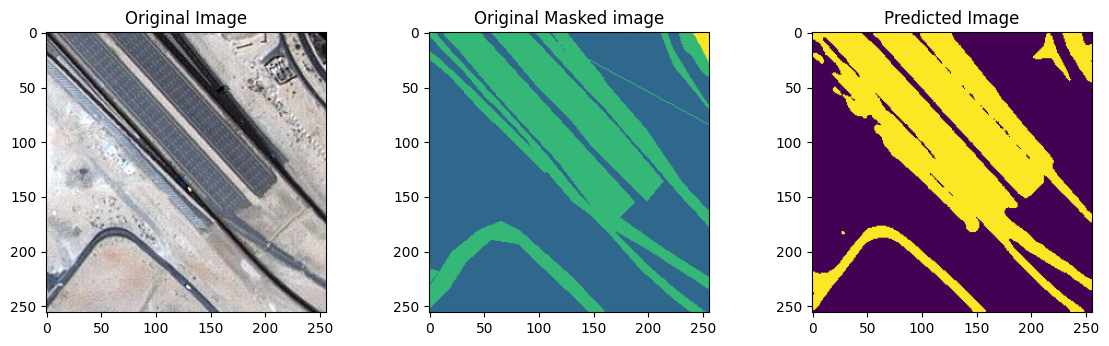

In [100]:
plt.figure(figsize=(14,8))
plt.subplot(231)
plt.title("Original Image")
plt.imshow(test_image)
plt.subplot(232)
plt.title("Original Masked image")
plt.imshow(ground_truth_image)
plt.subplot(233)
plt.title("Predicted Image")
plt.imshow(predicted_image)

In [101]:
model.save("satellite_segmentation_full.h5")

In [102]:
# The modern way to save in Keras 3
model.save("satellite_segmentation_full.keras")
print("Redundancy check complete: Both formats are now on your disk.")

Redundancy check complete: Both formats are now on your disk.


In [103]:

!ls -lah

total 77M
drwxr-xr-x 1 ASUS 197121    0 Mar 22 17:35 .
drwxr-xr-x 1 ASUS 197121    0 Mar 22 10:47 ..
-rw-r--r-- 1 ASUS 197121  30M Mar 22 10:23 archive (2).zip
drwxr-xr-x 1 ASUS 197121    0 Mar 22 11:00 land
-rw-r--r-- 1 ASUS 197121 2.4M Mar 22 17:36 land.ipynb
drwxr-xr-x 1 ASUS 197121    0 Mar 22 11:06 landextract
-rw-r--r-- 1 ASUS 197121  23M Mar 22 17:32 satellite_segmentation_full.h5
-rw-r--r-- 1 ASUS 197121  23M Mar 22 17:35 satellite_segmentation_full.keras


In [105]:
import keras
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")
print(f"Numpy Version: {np.__version__}")

TensorFlow Version: 2.21.0
Keras Version: 3.13.2
Numpy Version: 2.4.3


visualize model with keras


In [108]:
from keras.utils import plot_model

In [107]:
!pip install pydot graphviz


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [109]:
plot_model(model, to_file="satellite_model_plot.png", show_shapes=True, show_layer_names=True)


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [110]:
import keras
from IPython.display import clear_output

# This is a Jupyter magic command to show plots correctly
%matplotlib inline

print("✅ Setup initialized!")

✅ Setup initialized!


In [111]:
class PlotLoss(keras.callbacks.Callback):
  def on_train_begin(self, logs={}):
    self.i = 0
    self.x = []
    self.losses = []
    self.val_losses = []

    self.jaccard_coef = []
    self.val_jaccard_coef = []

    self.fig = plt.figure()
    self.logs = []

  def on_epoch_end(self, epoch, logs={}):
    self.logs.append(logs)
    self.x.append(self.i)
    # self.losses.append(logs.get('loss'))
    # self.val_losses.append(logs.get('val_loss'))

    self.jaccard_coef.append(logs.get('jaccard_coef'))
    self.val_jaccard_coef.append(logs.get('val_jaccard_coef'))

    self.i += 1
    
    clear_output(wait=True)
    # plt.plot(self.x, self.losses, label="loss")
    # plt.plot(self.x, self.val_losses, label="val_loss")

    plt.plot(self.x, self.jaccard_coef, label="jaccard_coef")
    plt.plot(self.x, self.val_jaccard_coef, label="val_jaccard_coef")

    plt.legend()
    plt.show();

plot_loss = PlotLoss()
     

In [102]:
class PlotLossEx(keras.callbacks.Callback):
  def on_train_begin(self, logs={}):
    self.i = 0
    self.x = []

    self.losses = []
    self.val_losses = []

    self.jaccard_coef = []
    self.val_jaccard_coef = []

    self.fig = plt.figure()
    self.logs = []

  def on_epoch_end(self, epoch, logs={}):
    self.logs.append(logs)
    self.x.append(self.i)

    self.losses.append(logs.get('loss'))
    self.val_losses.append(logs.get('val_loss'))

    self.jaccard_coef.append(logs.get('jaccard_coef'))
    self.val_jaccard_coef.append(logs.get('val_jaccard_coef'))

    self.i += 1

    plt.figure(figsize=(14,8))
    f, (graph1, graph2) = plt.subplots(1,2, sharex=True)
    
    clear_output(wait=True)

    graph1.set_yscale('log')
    graph1.plot(self.x, self.losses, label="loss")
    graph1.plot(self.x, self.val_losses, label="val_loss")
    graph1.legend()

    graph2.set_yscale('log')
    graph2.plot(self.x, self.jaccard_coef, label="jaccard_coef")
    graph2.plot(self.x, self.val_jaccard_coef, label="val_jaccard_coef")
    graph2.legend()

    plt.show();

plot_loss = PlotLossEx()
     

In [112]:
model_history = model.fit(X_train, y_train,
                          batch_size=16,
                          verbose=1,
                          epochs=10,
                          validation_data=(X_test, y_test),
                          callbacks=[plot_loss],
                          shuffle=False)
     

ValueError: You must call `compile()` before using the model.

<Figure size 1400x800 with 0 Axes>

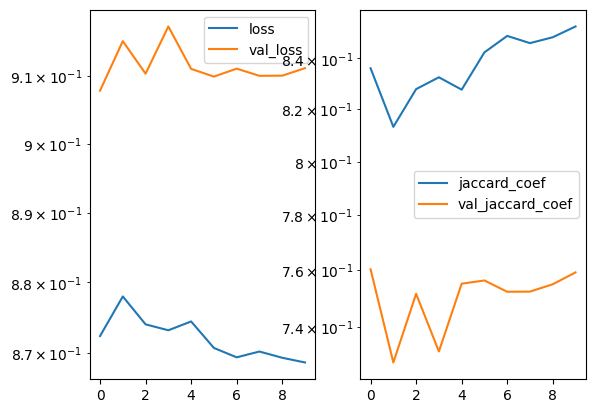

51/51 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9330 - jaccard_coef: 0.8528 - loss: 0.8686 - val_accuracy: 0.8717 - val_jaccard_coef: 0.7592 - val_loss: 0.9111


In [122]:
model_history = model.fit(X_train, y_train,
                          batch_size=16,
                          verbose=1,
                          epochs=10,
                          validation_data=(X_test, y_test),
                          callbacks=[plot_loss],
                          shuffle=False)
     

In [93]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from tensorflow.keras.utils import to_categorical

# 1. Get Model Predictions
# y_pred_probs shape: (N, 256, 256, 6)
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=-1)

# 2. Prepare Ground Truth
# If y_test is already categorical (One-Hot), convert back to Class IDs
if len(y_test.shape) == 4:
    y_true_classes = np.argmax(y_test, axis=-1)
else:
    y_true_classes = y_test

# 3. Flatten for Pixel-wise Analysis
# Every pixel is treated as a separate classification test
y_true_flat = y_true_classes.flatten()
y_pred_flat = y_pred_classes.flatten()

# 4. Define Class Names (As per your code's hex mapping)
class_names = ['Water', 'Land', 'Road', 'Building', 'Vegetation', 'Unlabeled']

# 5. Generate Precision, Recall, and F1-Score
print("--- TerraSeg: Detailed Classification Report ---")
print(classification_report(y_true_flat, y_pred_flat, target_names=class_names))

# 6. Calculate Overall Accuracy
acc = accuracy_score(y_true_flat, y_pred_flat)
print(f"Overall Pixel Accuracy: {acc:.4f}")

# 7. Calculate Multi-class ROC-AUC
# We use the raw probabilities and 'ovr' (One-vs-Rest) strategy
y_true_categorical = to_categorical(y_true_flat, num_classes=6)
y_pred_probs_flat = y_pred_probs.reshape(-1, 6)

roc_auc = roc_auc_score(y_true_categorical, y_pred_probs_flat, multi_class='ovr', average='weighted')
print(f"Weighted ROC-AUC Score: {roc_auc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 862ms/step
--- TerraSeg: Detailed Classification Report ---
              precision    recall  f1-score   support

       Water       0.93      0.93      0.93   1436569
        Land       0.87      0.93      0.90   5076462
        Road       0.73      0.71      0.72    733940
    Building       0.89      0.71      0.79   1179255
  Vegetation       0.80      0.72      0.76    853482
   Unlabeled       0.42      0.20      0.27     26404

    accuracy                           0.87   9306112
   macro avg       0.77      0.70      0.73   9306112
weighted avg       0.86      0.87      0.86   9306112

Overall Pixel Accuracy: 0.8660
Weighted ROC-AUC Score: 0.9607


In [114]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 1.2 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.7 MB 1.2 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.7 MB 1.5 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.7 MB 1.7 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.7 MB 1.8 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.7 MB 1.9 MB/s eta 0:00:04
   ------------ --------------------------- 3.1/9.7 MB 1.8 MB/s eta 0:00:04
   ------------- -------------------------- 3.4/9.7 MB 1.8 MB/s eta 0:00:04
   --------------- ------------------------ 3.7/9.7 MB 1.8 MB/s et


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 624ms/step


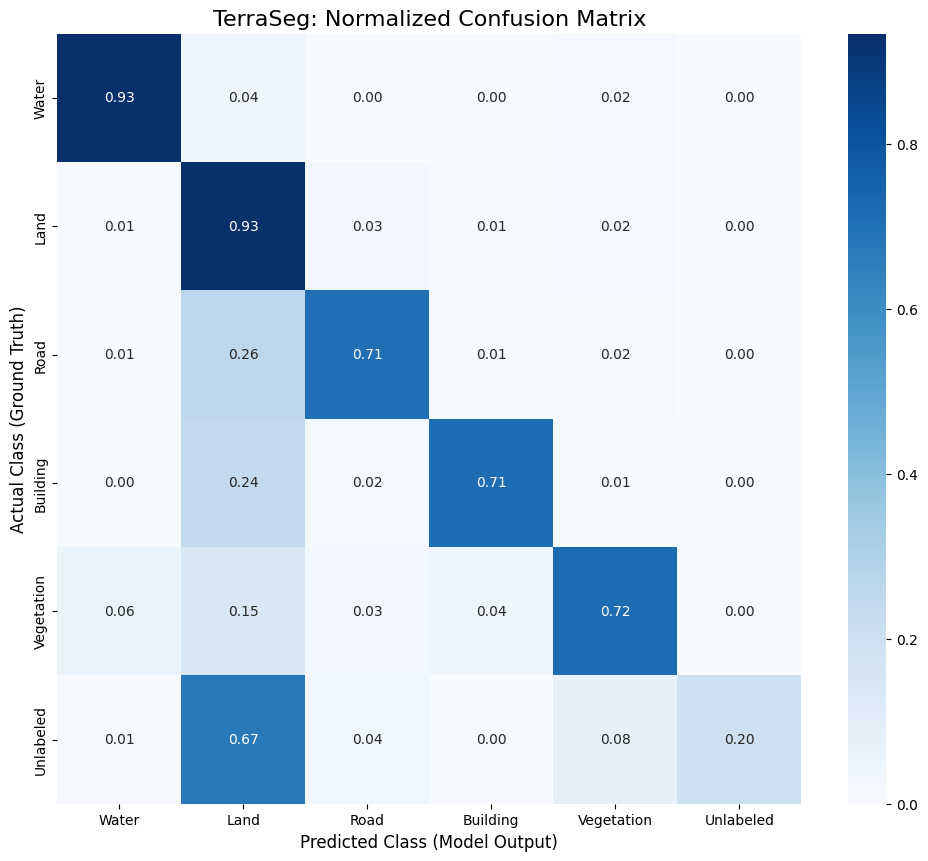

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Generate predictions for the test set
# This converts the (256, 256, 6) probability output to (256, 256) class IDs
y_pred = model.predict(X_test)
y_pred_argmax = np.argmax(y_pred, axis=3).flatten()
y_test_argmax = np.argmax(y_test, axis=3).flatten()

# 2. Define the 6 classes based on your hex mapping
class_names = ['Water', 'Land', 'Road', 'Building', 'Vegetation', 'Unlabeled']

# 3. Compute the Confusion Matrix
cm = confusion_matrix(y_test_argmax, y_pred_argmax)

# 4. Normalize the matrix (0.0 to 1.0) 
# This shows the percentage of correctly predicted pixels per class
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 5. Plot the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('TerraSeg: Normalized Confusion Matrix', fontsize=16)
plt.ylabel('Actual Class (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Class (Model Output)', fontsize=12)
plt.show()

In [118]:
from tensorflow.keras.utils import plot_model

# This creates a visual diagram of your ResU-Net
plot_model(model, 
           to_file='model_architecture_diagram.png', 
           show_shapes=True, 
           show_layer_names=True, 
           rankdir='TB', # TB = Top to Bottom
           dpi=96)

print("✅ Diagram generated as 'model_architecture_diagram.png'")

✅ Diagram generated as 'model_architecture_diagram.png'
